In [48]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc, mean_squared_error
import matplotlib.pyplot as plt
from surprise import Reader, Dataset, accuracy
from surprise.prediction_algorithms.knns import KNNWithMeans
from surprise.model_selection import cross_validate, KFold, train_test_split
# from surprise import Dataset
# from surprise import model_selection
# from surprise.model_selection import cross_validate
# from pandas.core.indexes.interval import maybe_extract_name
# from surprise.model_selection import KFold
# from surprise.model_selection.split import train_test_split

In [2]:
# Load datasets
users = pd.read_csv("movies.csv")
links = pd.read_csv("links.csv")
ratings = pd.read_csv("ratings.csv")
tags = pd.read_csv("tags.csv")

Q1A: Compute the sparsity of the movie rating dataset:

In [3]:
userIds = ratings['userId']
movieIds = ratings['movieId']
user_unique = userIds.unique()
movies_unique = movieIds.unique()

sparsity = len(ratings)/(len(user_unique)*len(movies_unique))
print('Sparsity:', sparsity)

Sparsity: 0.016999683055613623


Q1B: Plot a histogram showing the frequency of the rating values: 

Bin the raw rating values into intervals of width 0.5 and use the binned rating values as the horizontal axis. Count the
number of entries in the ratings matrix R that fall within each bin and use this count as the
height of the vertical axis for that particular bin. Comment on the shape of the histogram.

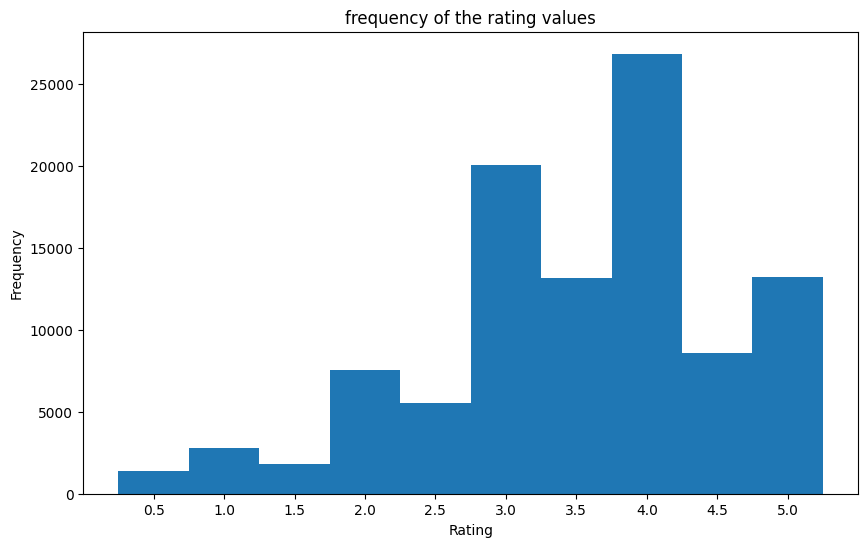

In [4]:
rate_values, indicies = np.unique(ratings['rating'].values, return_counts=True)
plt.figure(figsize=(10, 6))
plt.bar(rate_values, indicies, width=0.5)
plt.title('frequency of the rating values')
plt.xlabel('Rating')
plt.xticks(rate_values)
plt.ylabel('Frequency')
plt.show()

**Q1C Plot the distribution of the number of ratings received among movies:**

The X-axis should be the movie index ordered by decreasing frequency and the Y -axis should be the number
of ratings the movie has received; ties can broken in any way. A monotonically decreasing trend
is expected.

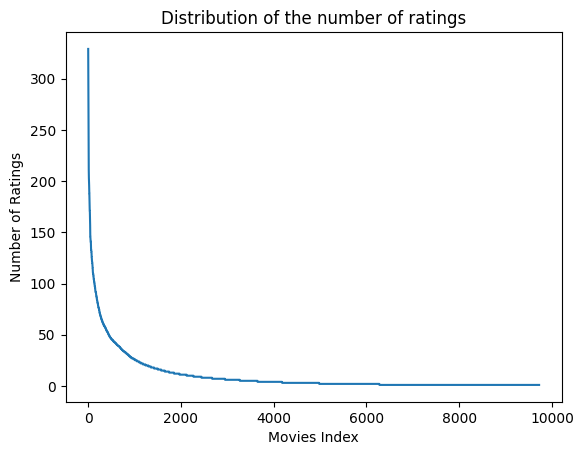

In [ ]:
movies, n_ratings = np.unique(movieIds.values, return_counts=True)
n_ratings = np.sort(n_ratings)
plt.figure(figsize=(10, 6))
plt.plot(n_ratings[::-1])
plt.title("Distribution of the number of ratings")
plt.xlabel("Movies Index")
plt.ylabel("Number of Ratings")
plt.show()

**Q1D Plot the distribution of ratings among users:**

The X-axis should be the user index ordered by decreasing frequency and the Y -axis should be the number of movies the user has rated.
The requirement of the plot is similar to that in Question C.

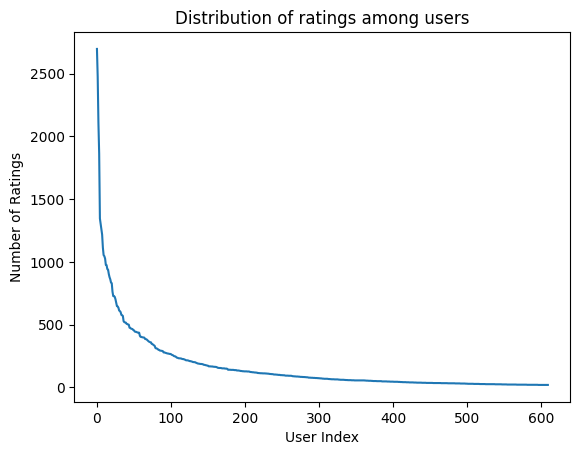

In [ ]:
users, n_ratings = np.unique(userIds.values, return_counts=True)
n_ratings = np.sort(n_ratings)
plt.figure(figsize=(10, 6))
plt.plot(n_ratings[::-1])
plt.title("Distribution of ratings among users")
plt.xlabel("User Index")
plt.ylabel("Number of Ratings")
plt.show()

**Q1E Discuss the salient features of the distributions from Questions C,D and their implications
for the recommendation process.**

From sections Q1C and Q1D, we can see that both distributions are exponentially decaying which tells us the following

- There is a subset of movies that are more popular and known by our users than others, and those movies are more commonly reviewed in comparison to those that fall outside of this subset.
- There is also a particular subset of our users that are more likely to review a film, while other users outside of this particular group provide less input

These implications mean that when we recommend content to our user base, we will have to utilize other means to create correlations between movies with low-user interactions to recommend them to the users who are most likely to enjoy the movie. Additionally, because a small concentration of users are providing the ratings it's likely that our recommendations may be skewed to the preferences of the group of active users and may not be an exact representation of the taste of our users.

**Q1F Compute the variance of the rating values received by each movie:**

Bin the variance values into intervals of width 0.5 and use the binned variance values as the horizontal axis.
Count the number of movies with variance values in the binned intervals and use this count as
the vertical axis. Briefly comment on the shape of the resulting histogram.

c:\Users\astro\repositories\UCLA\ECE 219\repo\.venv\Lib\site-packages\numpy\core\fromnumeric.py:3785: FutureWarning: The behavior of DataFrame.var with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return var(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


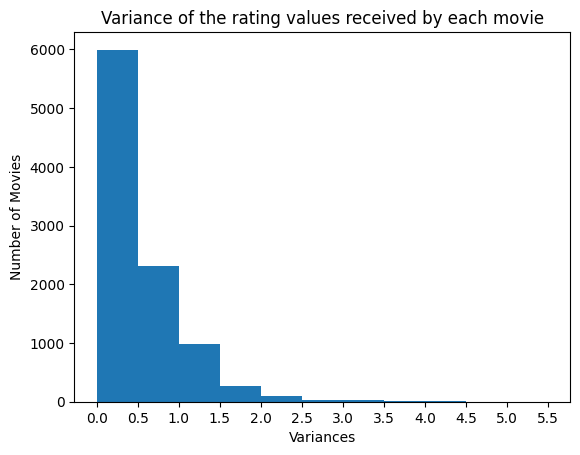

In [ ]:
rating_var = np.var(ratings.pivot_table("rating", "userId", "movieId")).values
plt.figure(figsize=(10, 6))
plt.hist(rating_var, bins=np.arange(0,6.0,0.5))
plt.xticks(np.arange(0,6.0,0.5))
plt.title("Variance of the rating values received by each movie")
plt.xlabel("Variances")
plt.ylabel("Number of Movies")
plt.show()

Based on the variance of ratings, we can see that most movies have a consistent rating value across our users and only a few where our users disagree, likely due to the subset of users that review many movies having similar tastes.

**Q2A: Write own the formula for $\mu_u$ in terms of $I_u$ and $r_{uk}$**

$$\mu_u = \frac{1}{|I_u|} \sum_{k \in I_u} r_{uk}$$

**Q2B In plain words, explain the meaning of $I_u$ $\cap$ $I_v$. Can $I_u$ $\cap$ $I_v$ = 0? (Hint: Rating matrix R is sparse)**

$I_u$ $\cap$ $I_v$ can indeed be $= 0$, is the intersetion of the two sets, in this case, the set are the movies that the user $u$ and $v$ have rated, and either they have no ratings across the same set of movies, or their ratings are different for all the mvoies in the set. 

**QUESTION 3: Understanding the Prediction function:** 

Can you explain the reason behind mean-centering the raw ratings (rvj − µv) in the prediction function? (Hint: Consider users who
either rate all items highly or rate all items poorly and the impact of these users on the prediction
function.)

The reason we rely on $(r_{vj} - \mu_v)$ is that we want to normalize our data and ensure that we are eliminating any biases in our dataset. Furthermore, the Pearson correlation accuracy is dependent on identifying the deviations from the user's average rating, thus if a user only rates 5's or 0's, without mean centering the correlation rating can be artificially high for these users leading to falsely identifying similarities where preferences might differ.

**Q4: Design a k-NN collaborative filter to predict the ratings of the movies in the original dataset and evaluate its performance using 10-fold cross validation.** 

Sweep k (number of neighbors) from 2 to 100 in step sizes of 2, and for each k compute the average RMSE and average
MAE obtained by averaging the RMSE and MAE across all 10 folds. Plot average RMSE (Y-axis)
against k (X-axis) and average MAE (Y-axis) against k (X-axis).

In [42]:
reader = Reader(rating_scale=(0.5, 5))
data = Dataset.load_from_df(df=ratings[['userId', 'movieId', 'rating']], reader=reader)
k_values = np.arange(2, 101, 2)

rmse_list = []
mae_list = []

for k in k_values:
    print('K Values =', k)
    sim_options = {'name': 'pearson', 'user_based': True}
    kNNwMeans = KNNWithMeans(k=k, sim_options=sim_options)
    cross_validation = cross_validate(kNNwMeans, data, measures=['rmse', 'mae'], cv=10, n_jobs=-1)
    rmse_list.append(np.mean(cross_validation['test_rmse']))
    mae_list.append(np.mean(cross_validation['test_mae']))
    print('Finished testing with k =', k)

K Values = 2
Finished testing with k = 2
K Values = 4
Finished testing with k = 4
K Values = 6
Finished testing with k = 6
K Values = 8
Finished testing with k = 8
K Values = 10
Finished testing with k = 10
K Values = 12
Finished testing with k = 12
K Values = 14
Finished testing with k = 14
K Values = 16
Finished testing with k = 16
K Values = 18
Finished testing with k = 18
K Values = 20
Finished testing with k = 20
K Values = 22
Finished testing with k = 22
K Values = 24
Finished testing with k = 24
K Values = 26
Finished testing with k = 26
K Values = 28
Finished testing with k = 28
K Values = 30
Finished testing with k = 30
K Values = 32
Finished testing with k = 32
K Values = 34
Finished testing with k = 34
K Values = 36
Finished testing with k = 36
K Values = 38
Finished testing with k = 38
K Values = 40
Finished testing with k = 40
K Values = 42
Finished testing with k = 42
K Values = 44
Finished testing with k = 44
K Values = 46
Finished testing with k = 46
K Values = 48
Finis

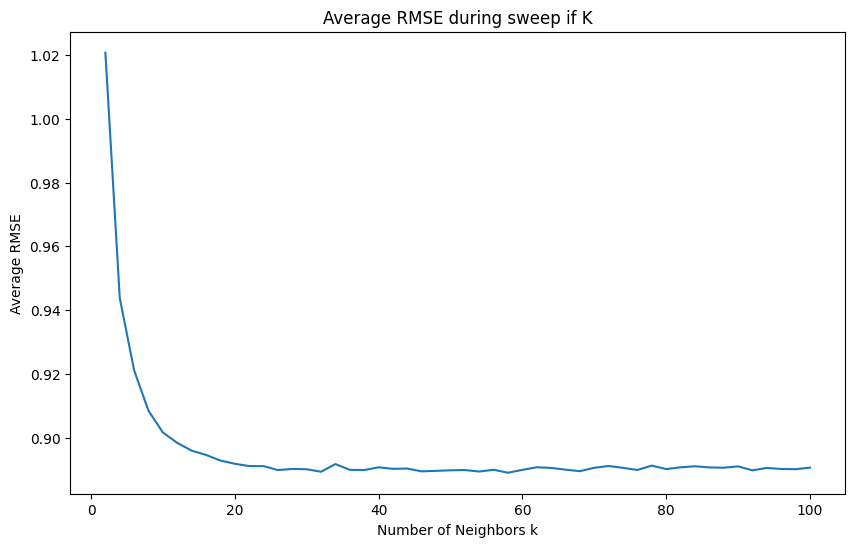

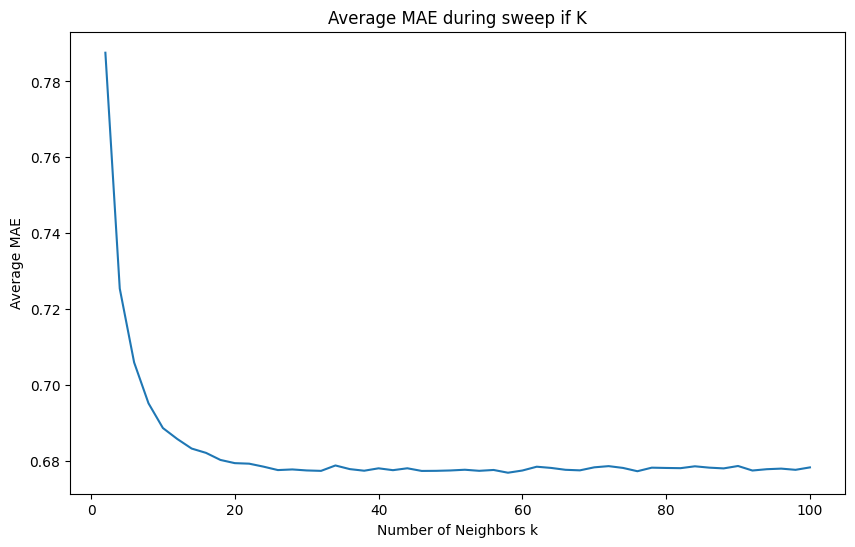

In [43]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, rmse_list)
plt.xlabel('Number of Neighbors k')
plt.ylabel('Average RMSE')
plt.title('Average RMSE during sweep if K')

plt.figure(figsize=(10, 6))
plt.plot(k_values, mae_list)
plt.xlabel('Number of Neighbors k')
plt.ylabel('Average MAE')
plt.title('Average MAE during sweep if K')
plt.show()

**QUESTION 5: Use the plot from question 4, to find a ’minimum k’:**

Note: The term ’minimum k’ in this context means that increasing k above the minimum value would not result in a significant
decrease in average RMSE or average MAE. If you get the plot correct, then ’minimum k’ would
correspond to the k value for which average RMSE and average MAE converges to a steady-state
value. Please report the steady state values of average RMSE and average MAE.

In [34]:
print('Steady state value of average RMSE:', rmse_list[12]) # k = 24 is the 12th entry in the list
print('Steady state value of average MAE:',mae_list[12]) # k = 24 is the 12th entry in the list

Steady state value of average RMSE: 0.8896345048832414
Steady state value of average MAE: 0.6777694594157315


Based on the graphs above we can see that our average for both RMSE and MAE stabalize roughly near $k = 24$, at this value both of our averages begin to stabalize and further increase $k$ will have little to no benefit for our results.

**QUESTION 6: Within EACH of the 3 trimmed subsets in the dataset, design (train and
validate):**

A k-NN collaborative filter on the ratings of the movies (i.e Popular, Unpopular or High-Variance)
and evaluate each of the three models’ performance using 10-fold cross validation:
- Sweep k (number of neighbors) from 2 to 100 in step sizes of 2, and for each k compute
the average RMSE obtained by averaging the RMSE across all 10 folds. Plot average RMSE
(Y-axis) against k (X-axis). Also, report the minimum average RMSE.
- Plot the ROC curves for the k-NN collaborative filters for threshold values [2.5, 3, 3.5, 4]. These
thresholds are applied only on the ground truth labels in held-out validation set. For each of
the plots, also report the area under the curve (AUC) value. You should have 4 × 4 plots in
this section (4 trimming options – including no trimming times 4 thresholds) - all thresholds
can be condensed into one plot per trimming option yielding only 4 plots.
We provide you with the following hints:
- Write trimming function that takes as input the set of data and outputs a trimmed set;
- For each value of k, split the trimmed dataset into 10 pairs of training and validation sets.
(trainset 1, testset 1), (trainset 2, testset 2), . . . , (trainset 10, testset 10)
The following documentation might be useful for the splitting:
http://surprise.readthedocs.io/en/stable/getting_started.html#use-cross-validation-iterators
- For each pair of (trainset, testset):
    - Train the collaborative filter on the trimmed train set
    - Predict the ratings of the movies in the trimmed validation set using the trained collaborative filter
    - Compute the RMSE of the predictions in the trimmed validation set
- Compute the average RMSE by averaging across all the 10 folds.
-  For the ROC plotting, split the dataset into 90% for training and 10% for validation. The functions described in the documentation below might be useful http://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html

In [38]:
def find_trim(data: Dataset, test, case=0):
    ref = {}
    for j in data.raw_ratings:
        if j[1] in ref.keys():
            ref[j[1]].append(j[2])
        else:
            ref[j[1]] = []
            ref[j[1]].append(j[2])
    
    if case == 0:        
        trim = [j for j in test if len(ref[j[1]]) > 2]
    elif case == 1:
        trim = [j for j in test if len(ref[j[1]]) <= 2]
    else:
        trim = [j for j in test if (np.var(ref[j[1]]) >= 2 and len(ref[j[1]]) >= 5)]
    
    return trim

In [ ]:
pop_RMSE = []
unpop_RMSE = []
highvar_RMSE = []
rmse_lists = [pop_RMSE, unpop_RMSE, highvar_RMSE]
kFolds =  KFold(n_splits=10)
for i in range(3):
    for k in k_values:
        cur_RMSE = []
        for train, test in kFolds.split(data):
            trim = find_trim(data, test, case=i)
            pred = KNNWithMeans(k=k, sim_options={'name':'pearson'}, verbose=False).fit(train).test(trim)
            cur_RMSE.append(accuracy.rmse(pred, verbose=False))
        
        print(f"Adding to list: {['pop_RMSE', 'unpop_RMSE', 'highvar_RMSE'][i]}, k = {k}")
        rmse_lists[i].append(np.mean(cur_RMSE))

Popular movie minimum RMSE: 0.8890132294958942
Unpopular movie minimum RMSE: 0.8888353841051876
Highvariance movie minimum RMSE: 0.8891204392084783


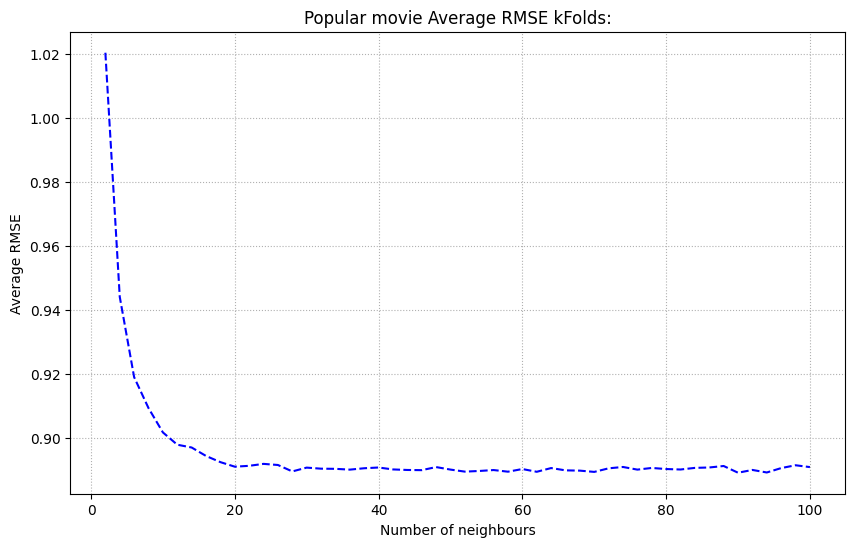

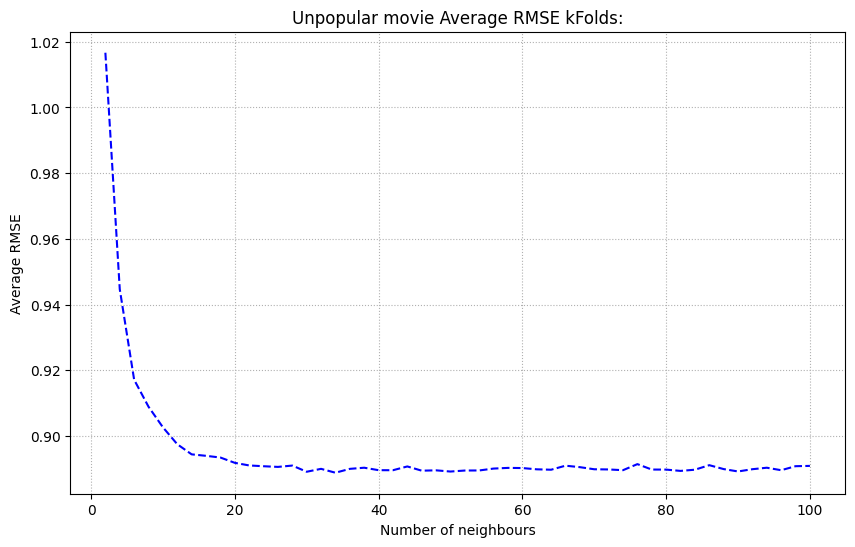

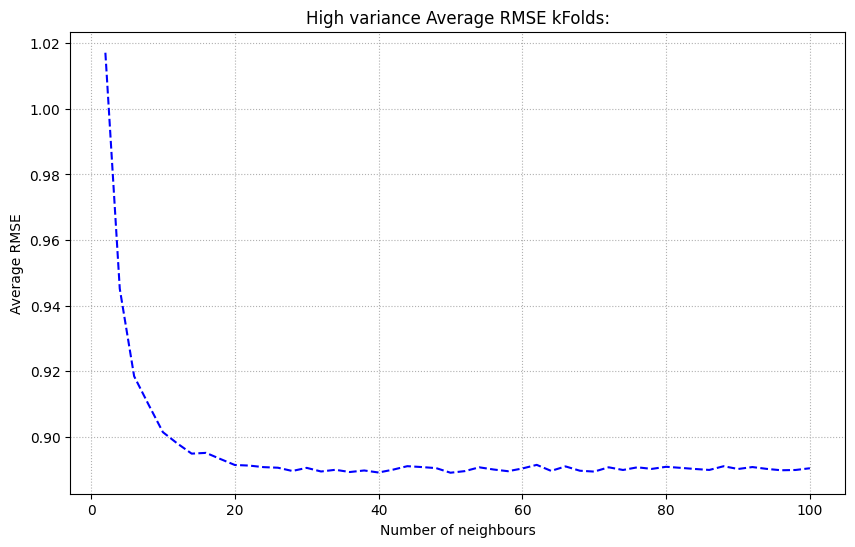

In [46]:
print("Popular movie minimum RMSE:", min(pop_RMSE))
print("Unpopular movie minimum RMSE:", min(unpop_RMSE))
print("Highvariance movie minimum RMSE:", min(highvar_RMSE))
plt.figure(figsize=(10, 6))
plt.plot(k_values, pop_RMSE,linestyle='--',color='b')
plt.grid(linestyle=':')
plt.title('Popular movie Average RMSE kFolds:')
plt.ylabel('Average RMSE')
plt.xlabel('Number of neighbours')
plt.figure(figsize=(10, 6))
plt.plot(k_values, unpop_RMSE,linestyle='--',color='b')
plt.grid(linestyle=':')
plt.title('Unpopular movie Average RMSE kFolds:')
plt.ylabel('Average RMSE')
plt.xlabel('Number of neighbours')
plt.figure(figsize=(10, 6))
plt.plot(k_values, highvar_RMSE,linestyle='--',color='b')
plt.grid(linestyle=':')
plt.title('High variance Average RMSE kFolds:')
plt.ylabel('Average RMSE')
plt.xlabel('Number of neighbours')
plt.show()

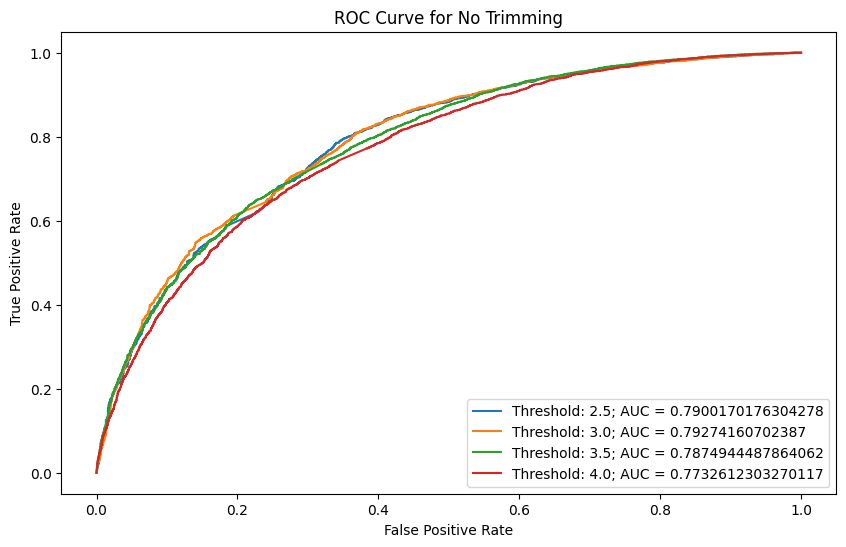

In [ ]:
thresholds = [2.5, 3.0, 3.5, 4.0]
trainset, testset = train_test_split(data, test_size=0.1)
sim_options = {'name': 'pearson', 'user_based': True}
preds = KNNWithMeans(k=25, sim_options=sim_options, verbose=False).fit(trainset).test(testset)

rates = [row.r_ui for row in preds]
pred_rates = [row.est for row in preds]
plt.figure(figsize=(10, 6))
for threshold in thresholds:
    label_rates = []
    for i in range(len(rates)):
        if rates[i] >= threshold:
            label_rates.append(1)
        else:
            label_rates.append(0)
            
    fpr, tpr, _ = roc_curve(label_rates, pred_rates)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label='Threshold: ' + str(threshold) + '; AUC = ' + str(roc_auc))
    
plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for No Trimming')
plt.show()

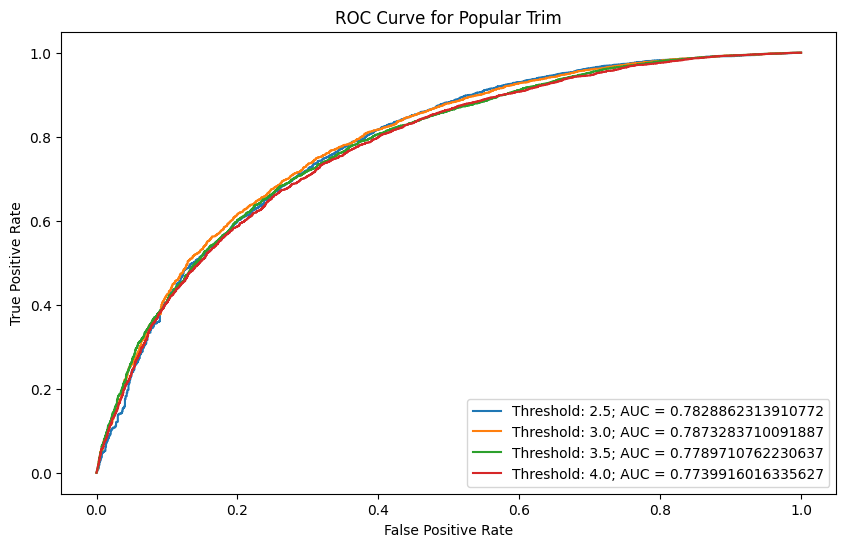

In [ ]:

Train_list, Test_list = train_test_split(data, test_size=0.1)
thresholds = [2.5, 3.0, 3.5, 4.0]
sim_options = {'name': 'pearson', 'user_based': True}
preds = KNNWithMeans(k=25, sim_options=sim_options, verbose=False).fit(Train_list).test(find_trim(data, Test_list, 0))

rates = [row.r_ui for row in preds]
pred_rates = [row.est for row in preds]
plt.figure(figsize=(10, 6))
for threshold in thresholds:
    label_rates = []
    for i in range(len(rates)):
        if rates[i] >= threshold:
            label_rates.append(1)
        else:
            label_rates.append(0)
            
    fpr, tpr, _ = roc_curve(label_rates, pred_rates)
    roc_auc = auc(fpr, tpr)        
    plt.plot(fpr, tpr, label='Threshold: ' + str(threshold) + '; AUC = ' + str(roc_auc))
    
plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Popular Trim')
plt.show()

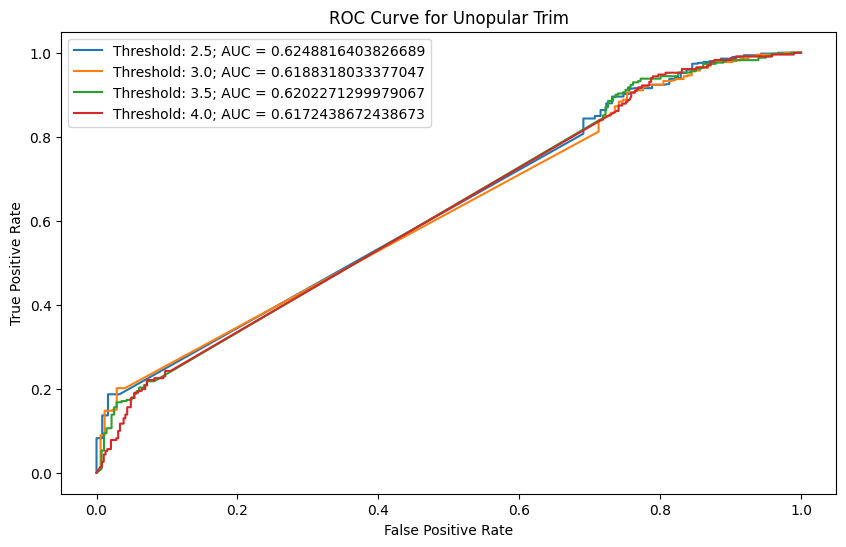

In [ ]:

Train_list, Test_list = train_test_split(data, test_size=0.1)
thresholds = [2.5, 3.0, 3.5, 4.0]
sim_options = {'name': 'pearson', 'user_based': True}
preds = KNNWithMeans(k=25, sim_options=sim_options, verbose=False).fit(Train_list).test(find_trim(data, Test_list, 1))

rates = [row.r_ui for row in preds]
pred_rates = [row.est for row in preds]
plt.figure(figsize=(10, 6))
for threshold in thresholds:
    label_rates = []
    for i in range(len(rates)):
        if rates[i] >= threshold:
            label_rates.append(1)
        else:
            label_rates.append(0)
            
    fpr, tpr, _ = roc_curve(label_rates, pred_rates)
    roc_auc = auc(fpr, tpr)        
    plt.plot(fpr, tpr, label='Threshold: ' + str(threshold) + '; AUC = ' + str(roc_auc))
    
plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Unopular Trim')
plt.show()

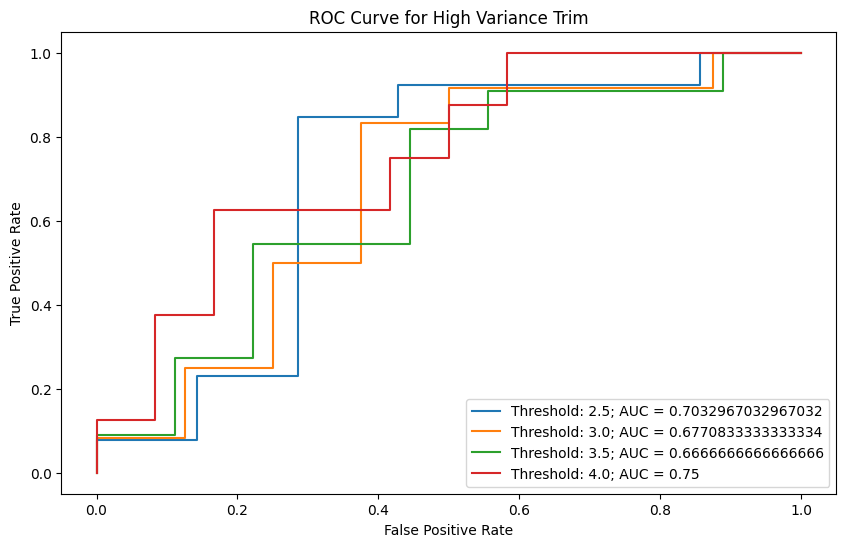

In [ ]:

Train_list, Test_list = train_test_split(data, test_size=0.1)
thresholds = [2.5, 3.0, 3.5, 4.0]
sim_options = {'name': 'pearson', 'user_based': True}
preds = KNNWithMeans(k=25, sim_options=sim_options, verbose=False).fit(Train_list).test(find_trim(data, Test_list, 2))

rates = [row.r_ui for row in preds]
pred_rates = [row.est for row in preds]
plt.figure(figsize=(10, 6))
for threshold in thresholds:
    label_rates = []
    for i in range(len(rates)):
        if rates[i] >= threshold:
            label_rates.append(1)
        else:
            label_rates.append(0)
            
    fpr, tpr, _ = roc_curve(label_rates, pred_rates)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label='Threshold: ' + str(threshold) + '; AUC = ' + str(roc_auc))
    
plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for High Variance Trim')
plt.show()